# MNIST

In [1]:
import sys
import torch

from utils.checkpoint import load_checkpoint, save_checkpoint
from utils.data import get_dataloaders

sys.path.append("..")

from models.mlp import Net as MLPNet
from models.lenet import Net as CNNNet
from config import Config


In [2]:
import os
%cd ./notebooks

/home/qosquo/dev/python/bayes_nn/notebooks


In [3]:
config = Config()
device = config.device

# Prepare data
_, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
mlp_model = MLPNet(
    prior_sigma1=config.prior_sigma1,
    prior_sigma2=config.prior_sigma2,
    prior_pi=config.prior_pi,
    num_classes=config.num_classes,
).to(device)
cnn_model = CNNNet(
    prior_sigma1=config.prior_sigma1,
    prior_sigma2=config.prior_sigma2,
    prior_pi=config.prior_pi,
    num_classes=config.num_classes,
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=config.learning_rate)
# Load weights
config.model_name = 'mnist_bnn_mlp'
load_checkpoint(mlp_model, optimizer, config.checkpoint_path, device)

config.model_name = 'mnist_bayesian_lenet_20251201'
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=config.learning_rate)
load_checkpoint(cnn_model, optimizer, config.checkpoint_path, device)

dict_keys(['model_state', 'optimizer_state', 'epoch'])
[checkpoint] Loaded from ../checkpoints/mnist_bnn_mlp.pth, starting at epoch 100
dict_keys(['model_state', 'optimizer_state', 'epoch'])
[checkpoint] Loaded from ../checkpoints/mnist_bayesian_lenet_20251201.pth, starting at epoch 477


477

In [4]:
import torch.nn.functional as F

def check_calibration(model, test_loader, T=20):
    """Check if model is properly calibrated"""
    model.train()

    all_confidences = []
    all_correct = []

    for data, targets in test_loader:
        # Get ensemble prediction
        predictions = []
        for _ in range(T):
            with torch.no_grad():
                logits = model(data)
                probs = F.softmax(logits, dim=1)
                predictions.append(probs)

        mean_probs = torch.stack(predictions).mean(0)
        max_probs, predicted = mean_probs.max(1)

        all_confidences.extend(max_probs.cpu().numpy())
        all_correct.extend((predicted == targets).cpu().numpy())

    # Expected Calibration Error (ECE)
    import numpy as np
    confidences = np.array(all_confidences)
    correct = np.array(all_correct)

    # Bin predictions by confidence
    bins = np.linspace(0, 1, 11)
    bin_indices = np.digitize(confidences, bins)

    print("\nCalibration Analysis:")
    print("Confidence | Accuracy | Count | Gap")
    print("-" * 45)

    ece = 0
    for i in range(1, 11):
        mask = bin_indices == i
        if mask.sum() > 0:
            bin_conf = confidences[mask].mean()
            bin_acc = correct[mask].mean()
            bin_count = mask.sum()
            gap = abs(bin_conf - bin_acc)
            ece += (bin_count / len(correct)) * gap

            print(f"{bin_conf:.3f}     | {bin_acc:.3f}    | {bin_count:5d} | {gap:.3f}")

    print(f"\nExpected Calibration Error: {ece:.4f}")
    print("(Lower is better, <0.05 is well-calibrated)")

    return ece

# Check both models
print("MLP Calibration:")
ece_mlp = check_calibration(mlp_model, test_loader, T=5)

print("\nCNN Calibration:")
ece_cnn = check_calibration(cnn_model, test_loader, T=5)

MLP Calibration:

Calibration Analysis:
Confidence | Accuracy | Count | Gap
---------------------------------------------
0.461     | 0.500    |     2 | 0.039
0.547     | 0.083    |    12 | 0.463
0.654     | 0.333    |    24 | 0.321
0.763     | 0.320    |    25 | 0.443
0.854     | 0.500    |    22 | 0.354
0.993     | 0.774    |   368 | 0.218

Expected Calibration Error: 0.0113
(Lower is better, <0.05 is well-calibrated)

CNN Calibration:

Calibration Analysis:
Confidence | Accuracy | Count | Gap
---------------------------------------------
0.272     | 0.333    |     3 | 0.061
0.362     | 0.350    |    20 | 0.012
0.461     | 0.545    |    55 | 0.084
0.557     | 0.635    |   104 | 0.077
0.649     | 0.756    |   127 | 0.107
0.759     | 0.918    |   182 | 0.159
0.855     | 0.969    |   360 | 0.115
0.992     | 0.999    |  9149 | 0.007

Expected Calibration Error: 0.0162
(Lower is better, <0.05 is well-calibrated)


In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from evaluate import evaluate_with_uncertainty

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform,
)
whole_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

output, uncertainties = evaluate_with_uncertainty(mlp_model, test_loader, device, mc_samples=5)
output, uncertainties = evaluate_with_uncertainty(cnn_model, test_loader, device, mc_samples=5)

Predictions: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0]
Aleatoric: 4.0494228414900135e-06
Epistemic: 8.060820760880105e-11
Predictions: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0]
Aleatoric: 0.015201310627162457
Epistemic: 0.024180961772799492


In [48]:
test(mlp_model, device, test_loader)


            Batch index: 0
            -------------
            Aleatoric: tensor([2.5720e-33, 0.0000e+00, 3.9573e-33, 0.0000e+00, 2.2239e-20, 5.3906e-28,
        1.9326e-35, 8.4397e-21, 2.5498e-29, 2.1961e-15, 0.0000e+00, 1.6816e-44,
        1.8519e-29, 0.0000e+00])
            

            Batch index: 1
            -------------
            Aleatoric: tensor([3.2862e-37, 5.3346e-34, 9.5217e-32, 1.4984e-19, 2.2447e-25, 2.9736e-42,
        1.6590e-11, 4.8029e-36, 0.0000e+00, 0.0000e+00, 1.8078e-23, 0.0000e+00,
        2.2962e-38, 0.0000e+00])
            

            Batch index: 2
            -------------
            Aleatoric: tensor([0.0000e+00, 4.8446e-27, 0.0000e+00, 1.1270e-28, 9.2205e-43, 0.0000e+00,
        1.2238e-39, 2.4565e-39, 4.5265e-30, 1.8098e-37, 7.4655e-33, 7.1403e-28,
        2.2208e-27, 1.0297e-02])
            

            Batch index: 3
            -------------
            Aleatoric: tensor([1.3749e-31, 4.8021e-30, 5.0651e-19, 7.2725e-36, 1.8554e-38, 0.0000

tensor(0.3697)

torch.Size([1, 28, 28])


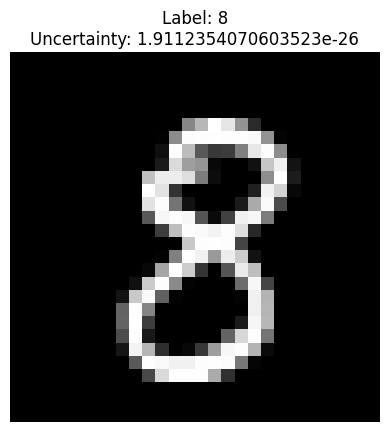

In [130]:
import matplotlib.pyplot as plt
from itertools import islice

# Get the i-th batch using islice
i = 665
data, target = next(islice(test_loader, i, i+1))
output, uncertainties = quantify_uncertainties(mlp_model, data, T=2)
# Get first image from batch
ind = 12
img = data[ind]
print(first_image.shape)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {target[ind].item()}\nUncertainty: {uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[ind]}')
plt.axis('off')
plt.show()

In [67]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    """
    Add salt and pepper noise to an image
    Args:
        image: torch tensor of shape (1, 28, 28) for MNIST
        salt_prob: probability of salt noise (white pixels)
        pepper_prob: probability of pepper noise (black pixels)
    """
    noisy_image = image.clone()
    
    # Create random mask for salt noise
    salt_mask = torch.rand_like(image) < salt_prob
    # Create random mask for pepper noise  
    pepper_mask = torch.rand_like(image) < pepper_prob
    
    # Apply salt noise (set to 1)
    noisy_image[salt_mask] = 1.0
    # Apply pepper noise (set to 0)
    noisy_image[pepper_mask] = 0.0
    
    return noisy_image

def add_salt_pepper_noise_normalized(image, salt_prob=0.05, pepper_prob=0.05, data_mean=0.1307, data_std=0.3081):
    """
    Add salt and pepper noise to a NORMALIZED MNIST image
    """
    noisy_image = image.clone()
    
    # Calculate normalized values for min (0) and max (1)
    normalized_min = (0.0 - data_mean) / data_std  # ≈ -0.424
    normalized_max = (1.0 - data_mean) / data_std  # ≈ 2.823
    
    # Create random masks
    salt_mask = torch.rand_like(image) < salt_prob
    pepper_mask = torch.rand_like(image) < pepper_prob
    
    # Apply salt noise (set to normalized max)
    noisy_image[salt_mask] = normalized_max
    # Apply pepper noise (set to normalized min)  
    noisy_image[pepper_mask] = normalized_min
    
    return noisy_image

In [109]:
def display_images_with_uncertainty(model, test_loader, batch_idx=0, img_idx=0, salt_prob=0.05, pepper_prob=0.05, T=5):
    # Get the i-th batch using islice
    data, target = next(islice(test_loader, batch_idx, batch_idx+1))
    output, uncertainties = quantify_uncertainties(model, data, T)

    # Get first image from batch
    img = data[img_idx]
    print(f"Original image shape: {img.shape}")

    # Add salt and pepper noise to the image
    noisy_img = add_salt_pepper_noise_normalized(img, salt_prob=salt_prob, pepper_prob=pepper_prob)

    # Create subplots to compare original and noisy images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Plot original image
    ax1.imshow(img.squeeze(), cmap='gray')
    ax1.set_title(f'Original\nLabel: {target[img_idx].item()}')
    ax1.axis('off')

    # Plot noisy image
    ax2.imshow(noisy_img.squeeze(), cmap='gray')
    ax2.set_title('Noisy')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

    # You can also quantify uncertainties for the noisy image
    noisy_data = noisy_img.unsqueeze(0)  # Add batch dimension
    noisy_output, noisy_uncertainties = quantify_uncertainties(model, noisy_data, T)

    print(f"Original uncertainty: {uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")
    print(f"Noisy uncertainty: {noisy_uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[0]}")
    print(f"Noisy correct: {noisy_output[0].item() == target[img_idx].item()} ({noisy_output[0].item()})")

Original image shape: torch.Size([1, 28, 28])


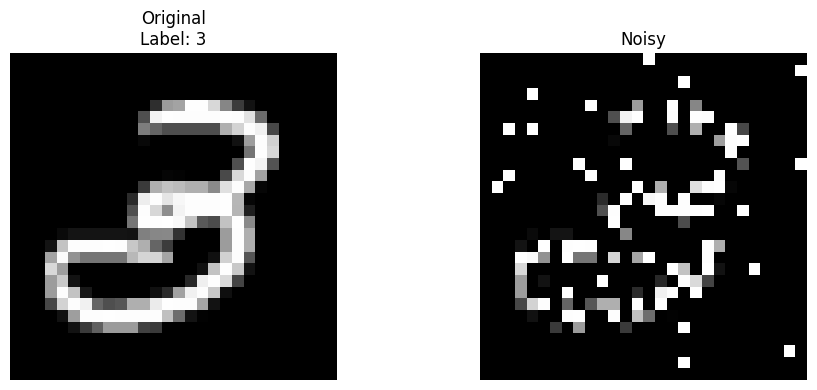

Original uncertainty: 0.1266605257987976
Noisy uncertainty: 0.0005137455882504582
Noisy correct: False (8)


In [115]:
# Цифра 3
display_images_with_uncertainty(mlp_model, test_loader, batch_idx=695, img_idx=12, salt_prob=0.1, pepper_prob=0.5, T=15)

Original image shape: torch.Size([1, 28, 28])


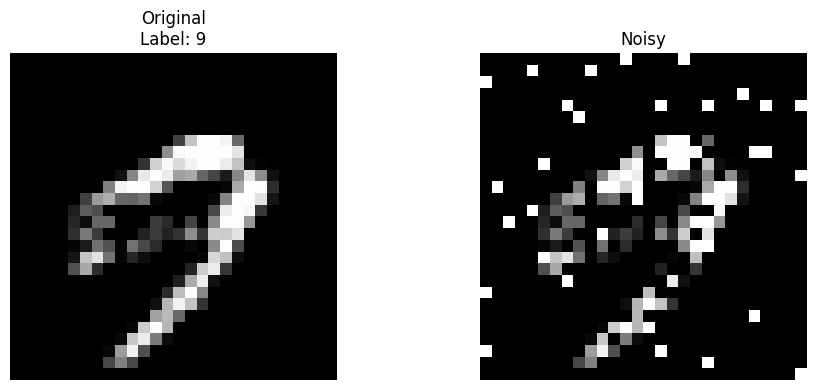

Original uncertainty: 2.2605722733715083e-06
Noisy uncertainty: 0.033225663006305695
Noisy correct: False (7)


In [120]:
# Цифра 9
display_images_with_uncertainty(mlp_model, test_loader, batch_idx=688, img_idx=10, salt_prob=0.05, pepper_prob=0.3, T=15)

Original image shape: torch.Size([1, 28, 28])


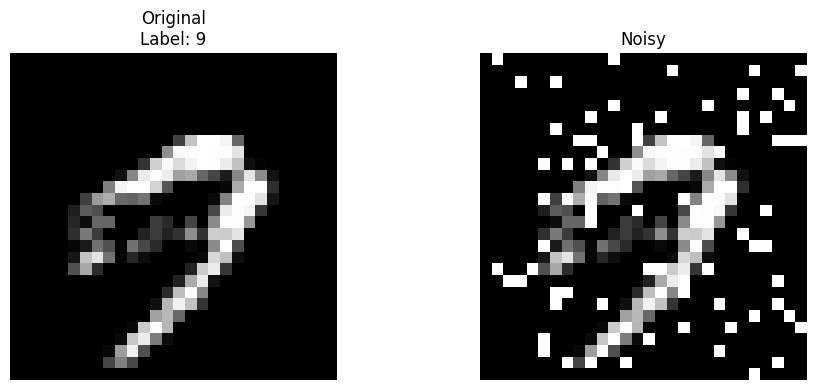

Original uncertainty: 5.4496791562996805e-05
Noisy uncertainty: 4.253650320862334e-09
Noisy correct: False (7)


In [124]:
# Цифра 9
display_images_with_uncertainty(mlp_model, test_loader, batch_idx=688, img_idx=10, salt_prob=0.1, pepper_prob=0.01, T=15)

## Save model

In [17]:
import os
if save_model:
    #   from google.colab import drive
    #   drive.mount('/content/drive')
    #   model_dir = '/content/drive/MyDrive/mnist_bnn'
    #   weights_path = os.path.join(os.path(__file__), 'mnist_bnn.pth')

      torch.save(mlp_model.state_dict(), 'mnist_bnn.pth')
      checkpoint = {
          'epoch': 107,
          'model_state_dict': mlp_model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'learning_rate': scheduler.get_last_lr() if scheduler else 0.001
      }
      print(checkpoint)

    #   checkpoints_path = os.path.join(os.path(__file__), 'checkpoints', 'mnist_bnn_20251124.pth')
      torch.save(checkpoint, 'checkpoints/mnist_bnn_20251124.pth')

{'epoch': 107, 'model_state_dict': OrderedDict({'fc1.mu': tensor([[ 0.1960,  0.1523,  0.0939,  ...,  0.0808, -0.0720, -0.0902],
        [ 0.0625,  0.0688,  0.1350,  ...,  0.1020,  0.0614,  0.0043],
        [ 0.0247,  0.0115, -0.0863,  ...,  0.1572,  0.1048, -0.0014],
        ...,
        [ 0.2378,  0.1419, -0.1440,  ..., -0.0653,  0.0040, -0.0958],
        [ 0.0412,  0.0413, -0.0072,  ..., -0.1255,  0.1066,  0.0497],
        [ 0.0526,  0.0711,  0.2462,  ...,  0.2453,  0.2063,  0.1696]]), 'fc1.rho': tensor([[-4.2542, -4.3976, -4.4889,  ..., -4.2381, -4.3703, -5.0509],
        [-4.5874, -3.8396, -4.3624,  ..., -4.2816, -4.1069, -4.8941],
        [-4.1842, -4.6861, -4.2429,  ..., -4.4132, -4.2892, -4.1487],
        ...,
        [-4.5597, -4.4759, -3.9102,  ..., -4.1289, -4.3828, -4.6403],
        [-4.5463, -4.1014, -3.8366,  ..., -4.6402, -4.6911, -4.3338],
        [-4.4412, -4.1427, -4.5775,  ..., -4.1230, -4.7345, -4.4269]]), 'fc1.mu_bias': tensor([ 9.6233e-03, -2.4886e-02, -1.3816e-02,

In [10]:
def load_weights_from_drive(filename, device, model):
    """Load checkpoint from Google Drive"""
    model_dir = os.getcwd()
    filepath = os.path.join(model_dir, filename)

    if not os.path.exists(filepath):
        print(f"Weights not found: {filepath}")
        return None

    # Load to CPU first, then move to appropriate device
    weights = torch.load(filepath, map_location=device)

    # Load model weights
    model.load_state_dict(weights)
    print("Weights loaded successfully!")

mlp_model = Net().to(device)
load_weights_from_drive('mnist_bnn.pth', device, mlp_model)

Weights loaded successfully!
